# Pharmaceutical drugs and vitamins Classification using Deep Convolutional Neural Networks and Transfer Learning

The dataset used includes images of popular pharmaceutical drugs and vitamins in the Philippines. This is a notebook that aims to classify these images using CNN and transfer learning.

**Important Note:** This notebook is not a part of a research study or peer-reviewed article that has been heavily reviewed and lawfully accepted by several medical institutions. The dataset was not reviewed by any Pharmaceutical authority or any practitioner that is knowledgeable with the field. The use of the dataset is encouraged for educational purposes only as it may impose ethical problems or may cause harm for others if improperly utilized. It is advised to not use this dataset for your own machine learning applications or services without prior peer-review by an expert in the field of medicine or any law making authority that is responsible for the ethical use of medical dataset. Please take this into consideration.

## Import Necessary Libraries

In [1]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras_preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.layers.experimental import preprocessing

In [3]:
# System libraries
from pathlib import Path
import os.path

In [4]:
# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

## Create helper functions

In [5]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

--2022-08-16 16:19:36--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2022-08-16 16:19:36 (43.0 MB/s) - ‘helper_functions.py’ saved [10246/10246]



## Load and transform data

In [6]:
BATCH_SIZE = 32
IMAGE_SIZE = (300, 300)

In [7]:
# Walk through each directory
dataset = "../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined"
walk_through_dir(dataset)

There are 10 directories and 0 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/DayZinc'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/Alaxan'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/Decolgen'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/Bactidol'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/Medicol'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Combined/Kremil S'.
There are 0 directories and 1000 images in '../input/pharmaceutical-drugs-and-vitamins-synthetic-images/Data Com

### Placing data into a Dataframe
The first column `filepaths` contains the file path location of each individual images. The second column `labels`, on the other hand, contains the class label of the corresponding image from the file path

In [8]:
image_dir = Path(dataset)

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png')) + list(image_dir.glob(r'**/*.png'))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

In [9]:
image_df

,Filepath,Label
0,../input/pharmaceutical-drugs-and-vitamins-syn...,DayZinc
1,../input/pharmaceutical-drugs-and-vitamins-syn...,DayZinc
2,../input/pharmaceutical-drugs-and-vitamins-syn...,DayZinc
3,../input/pharmaceutical-drugs-and-vitamins-syn...,DayZinc
4,../input/pharmaceutical-drugs-and-vitamins-syn...,DayZinc
...,...,...
9995,../input/pharmaceutical-drugs-and-vitamins-syn...,Bioflu
9996,../input/pharmaceutical-drugs-and-vitamins-syn...,Bioflu
9997,../input/pharmaceutical-drugs-and-vitamins-syn...,Bioflu
9998,../input/pharmaceutical-drugs-and-vitamins-syn...,Bioflu


### Visualizing images from the dataset

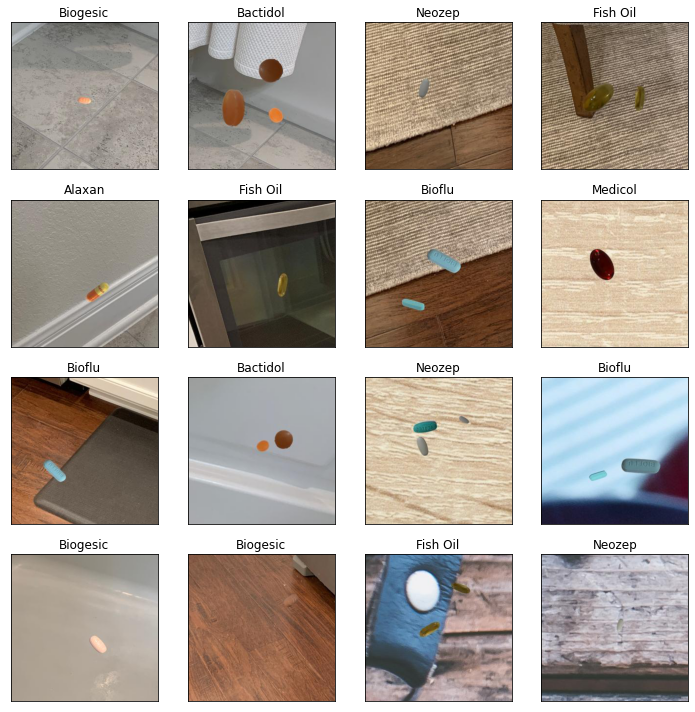

In [10]:
# Display 16 picture of the dataset with their labels
random_index = np.random.randint(0, len(image_df), 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[random_index[i]]))
    ax.set_title(image_df.Label[random_index[i]])
plt.tight_layout()
plt.show()

## Data Preprocessing
The data will be split into three different categories: Training, Validation and Testing. The training data will be used to train the deep learning CNN model and its parameters will be fine tuned with the validation data. Finally, the performance of the data will be evaluated using the test data(data the model has not previously seen).

In [11]:
# Separate in train and test data
train_df, test_df = train_test_split(image_df, test_size=0.2, shuffle=True, random_state=42)

In [12]:
train_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [13]:
# Split the data into three categories.
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 6400 validated image filenames belonging to 10 classes.
Found 1600 validated image filenames belonging to 10 classes.
Found 2000 validated image filenames belonging to 10 classes.


In [14]:
# Resize Layer
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(224,224),
  layers.experimental.preprocessing.Rescaling(1./255),
])

2022-08-16 16:19:41.500745: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-08-16 16:19:41.650096: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-08-16 16:19:41.651038: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-08-16 16:19:41.652731: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

## Training the model
The model images will be subjected to a pre-trained CNN model called MobileNetV2. Three callbacks will be utilized to monitor the training. These are: Model Checkpoint, Early Stopping, Tensorboard callback. The summary of the model hyperparameter is shown as follows:

**Batch size** : 32

**Epochs** : 100

**Input Shape** : (224, 224, 3)

**Output layer** : 10



In [15]:
# Load the pretained model
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9420800/9406464 [==============================] - 0s 0us/step


In [16]:
# Create checkpoint callback
checkpoint_path = "pharmaceutical_drugs_and_vitamins_classification_model_checkpoint"
checkpoint_callback = ModelCheckpoint(checkpoint_path,
                                      save_weights_only=True,
                                      monitor="val_accuracy",
                                      save_best_only=True)

In [17]:
# Setup EarlyStopping callback to stop training if model's val_loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(monitor = "val_loss", # watch the val loss metric
                               patience = 5,
                               restore_best_weights = True) # if val loss decreases for 3 epochs in a row, stop training

### Training the model

In [18]:
inputs = pretrained_model.input
x = resize_and_rescale(inputs)

x = Dense(256, activation='relu')(pretrained_model.output)
x = Dropout(0.2)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)


outputs = Dense(10, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=100,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", 
                                    "drug_classification"),
        checkpoint_callback,
    ]
)

2022-08-16 16:19:45.795209: I tensorflow/core/profiler/lib/profiler_session.cc:131] Profiler session initializing.
2022-08-16 16:19:45.795255: I tensorflow/core/profiler/lib/profiler_session.cc:146] Profiler session started.
2022-08-16 16:19:45.797165: I tensorflow/core/profiler/internal/gpu/cupti_tracer.cc:1614] Profiler found 1 GPUs
2022-08-16 16:19:46.023511: I tensorflow/core/profiler/lib/profiler_session.cc:164] Profiler session tear down.
2022-08-16 16:19:46.023701: I tensorflow/core/profiler/internal/gpu/cupti_tracer.cc:1748] CUPTI activity buffer flushed


Saving TensorBoard log files to: training_logs/drug_classification/20220816-161945


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
2022-08-16 16:19:46.466560: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/100


2022-08-16 16:19:50.680703: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


...

  2/200 [..............................] - ETA: 1:24 - loss: 2.4817 - accuracy: 0.0938 

2022-08-16 16:19:56.869471: I tensorflow/core/profiler/lib/profiler_session.cc:66] Profiler session collecting data.
2022-08-16 16:19:56.870880: I tensorflow/core/profiler/internal/gpu/cupti_tracer.cc:1748] CUPTI activity buffer flushed
2022-08-16 16:19:57.022521: I tensorflow/core/profiler/internal/gpu/cupti_collector.cc:673]  GpuTracer has collected 312 callback api events and 309 activity events. 
2022-08-16 16:19:57.035195: I tensorflow/core/profiler/lib/profiler_session.cc:164] Profiler session tear down.
2022-08-16 16:19:57.054947: I tensorflow/core/profiler/rpc/client/save_profile.cc:136] Creating directory: training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57

2022-08-16 16:19:57.064193: I tensorflow/core/profiler/rpc/client/save_profile.cc:142] Dumped gzipped tool data for trace.json.gz to training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57/b1555a257a86.trace.json.gz


  3/200 [..............................] - ETA: 1:10 - loss: 2.4708 - accuracy: 0.1354

2022-08-16 16:19:57.105860: I tensorflow/core/profiler/rpc/client/save_profile.cc:136] Creating directory: training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57

2022-08-16 16:19:57.113247: I tensorflow/core/profiler/rpc/client/save_profile.cc:142] Dumped gzipped tool data for memory_profile.json.gz to training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57/b1555a257a86.memory_profile.json.gz
2022-08-16 16:19:57.115133: I tensorflow/core/profiler/rpc/client/capture_profile.cc:251] Creating directory: training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57
Dumped tool data for xplane.pb to training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57/b1555a257a86.xplane.pb
Dumped tool data for overview_page.pb to training_logs/drug_classification/20220816-161945/train/plugins/profile/2022_08_16_16_19_57/b1555a257a86.overview_page.pb
Dumped tool data

200/200 [==============================] - 54s 221ms/step - loss: 1.6962 - accuracy: 0.4355 - val_loss: 0.9440 - val_accuracy: 0.7394
Epoch 2/100
200/200 [==============================] - 27s 133ms/step - loss: 0.9305 - accuracy: 0.6942 - val_loss: 0.6478 - val_accuracy: 0.7944
Epoch 3/100
200/200 [==============================] - 26s 129ms/step - loss: 0.7106 - accuracy: 0.7631 - val_loss: 0.5613 - val_accuracy: 0.8306
Epoch 4/100
200/200 [==============================] - 25s 126ms/step - loss: 0.5927 - accuracy: 0.8019 - val_loss: 0.5074 - val_accuracy: 0.8313
Epoch 5/100
200/200 [==============================] - 27s 134ms/step - loss: 0.5163 - accuracy: 0.8228 - val_loss: 0.4803 - val_accuracy: 0.8469
Epoch 6/100
200/200 [==============================] - 27s 137ms/step - loss: 0.4638 - accuracy: 0.8458 - val_loss: 0.4656 - val_accuracy: 0.8456
Epoch 7/100
200/200 [==============================] - 27s 137ms/step - loss: 0.4179 - accuracy: 0.8562 - val_loss: 0.4403 - val_accurac

## Model Evaluation
The test dataset will be used to evaluate the performance of the model.One of the metrics that will be tested would be accuracy which measures the fraction of predictions the model got right. Other metrics are as follows:

**Precision(P)**: 
The fraction of true positives (TP, correct predictions) from the total amount of relevant results, i.e., the sum of TP and false positives (FP). For multi-class classification problems, P is averaged among the classes. The following is the formula for precision.

<center>$P=TP/(TP+FP)$</center>

**Recall(R)**: 
The fraction of TP from the total amount of TP and false negatives (FN). For multi-class classification problems, R gets averaged among all the classes. The following is the formula for recall.
<center>$R=TP/(TP+FN)$</center>

**F1 score(F1)**: 
The harmonic mean of precision and recall. For multi-class classification problems, F1 gets averaged among all the classes. The following is the formula for F1 score.
<center>$F1=2 * (TP * FP)/(TP+FP)$</center>



In [19]:
results = model.evaluate(test_images, verbose=0)

print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.47399
Test Accuracy: 84.35%


### Visualizing loss curves

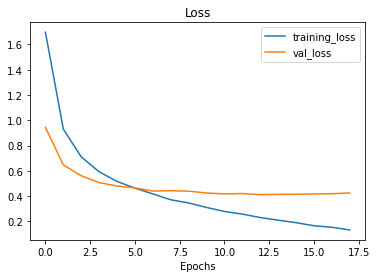

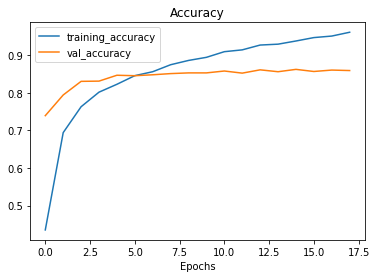

In [20]:
plot_loss_curves(history)

### Making predictions on the test data

In [21]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

# Display the result
print(f'The first 5 predictions: {pred[:5]}')

The first 5 predictions: ['Biogesic', 'Medicol', 'Alaxan', 'Medicol', 'Medicol']


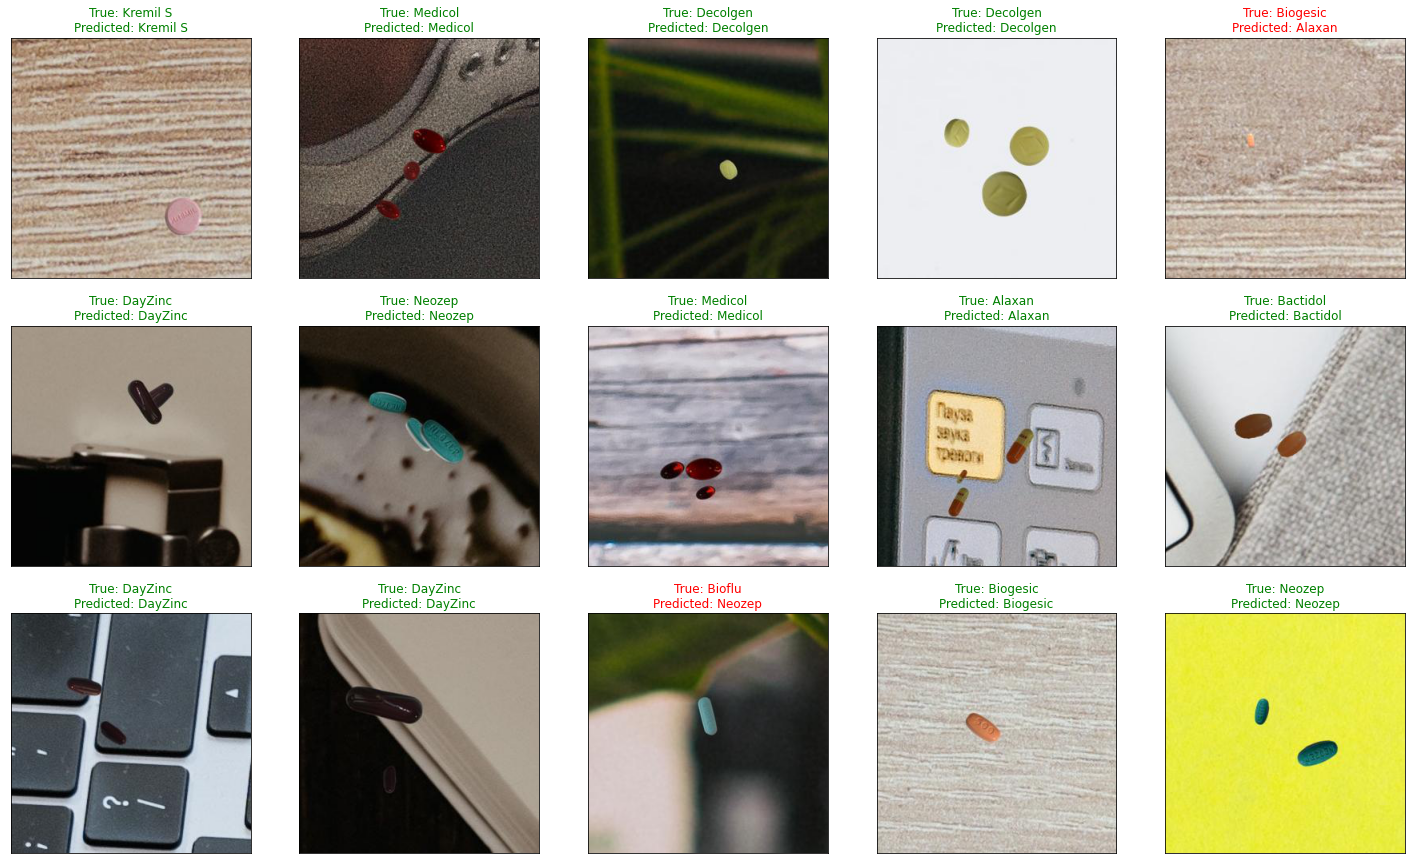

<Figure size 432x288 with 0 Axes>

In [22]:
  # Display 25 random pictures from the dataset with their labels
random_index = np.random.randint(0, len(test_df) - 1, 15)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[random_index[i]]))
    if test_df.Label.iloc[random_index[i]] == pred[random_index[i]]:
      color = "green"
    else:
      color = "red"
    ax.set_title(f"True: {test_df.Label.iloc[random_index[i]]}\nPredicted: {pred[random_index[i]]}", color=color)
plt.show()
plt.tight_layout()

### Plotting the classification reports and confusion matrix

In [23]:
y_test = list(test_df.Label)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Alaxan       0.79      0.86      0.82       202
    Bactidol       0.83      0.85      0.84       201
      Bioflu       0.89      0.87      0.88       175
    Biogesic       0.74      0.77      0.75       211
     DayZinc       0.82      0.87      0.84       208
    Decolgen       0.91      0.90      0.90       192
    Fish Oil       0.90      0.85      0.88       212
    Kremil S       0.81      0.76      0.78       186
     Medicol       0.94      0.95      0.94       209
      Neozep       0.83      0.76      0.79       204

    accuracy                           0.84      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



In [24]:
report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()
df

,precision,recall,f1-score,support
Alaxan,0.793578,0.856436,0.823810,202.0000
Bactidol,0.834146,0.850746,0.842365,201.0000
Bioflu,0.889535,0.874286,0.881844,175.0000
Biogesic,0.737557,0.772512,0.754630,211.0000
DayZinc,0.818182,0.865385,0.841121,208.0000
Decolgen,0.905263,0.895833,0.900524,192.0000
Fish Oil,0.900498,0.853774,0.876513,212.0000
Kremil S,0.805714,0.758065,0.781163,186.0000
Medicol,0.938389,0.947368,0.942857,209.0000
Neozep,0.828877,0.759804,0.792839,204.0000


In [25]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 7), text_size=10, norm=False, savefig=False): 
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).
  
  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """  
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])
  
  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes), 
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)
  
  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=90, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")


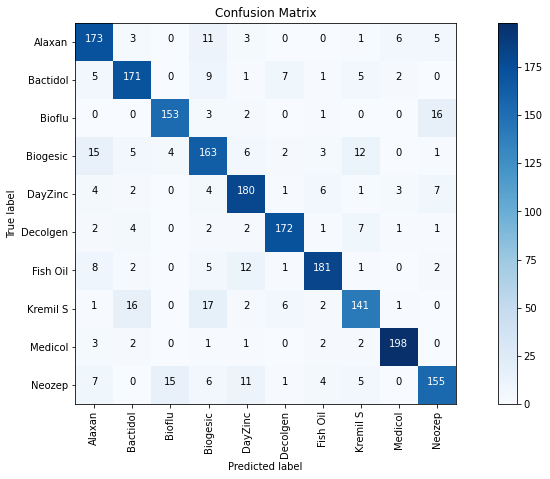

In [26]:
make_confusion_matrix(y_test, pred, list(labels.values()))